# Previsão de Vitória em Partidas Ranqueadas de League of Legends

Imagine que, antes mesmo de uma partida de League of Legends realmente se desenvolver, fosse possível estimar qual equipe possui maior chance de vencer apenas analisando as primeiras informações do jogo.

Foi exatamente esse desafio que motivou este projeto.

À primeira vista, prever o vencedor de uma partida pode parecer simples, afinal existem estatísticas de cada equipe. Porém, quando começamos a analisar os dados, percebemos que diversas informações estavam altamente relacionadas entre si, havia variáveis redundantes, diferenças entre estatísticas dos dois times e dezenas de atributos que poderiam confundir um modelo de Machine Learning.

O primeiro passo foi compreender profundamente a base de dados. Antes de pensar em algoritmos, foi necessário entender o significado de cada variável, identificar possíveis inconsistências e descobrir quais informações realmente agregavam valor para a previsão.

Com a exploração dos dados, surgiram alguns padrões interessantes. Algumas estatísticas apresentavam forte relação com a vitória, enquanto outras praticamente não contribuíam para explicar o resultado da partida. Isso mostrou que apenas possuir muitos dados não significa possuir boas informações.

Na etapa seguinte, o projeto passou por uma preparação criteriosa dos dados. Foram removidas variáveis que não agregavam informação ao modelo, tratadas possíveis inconsistências e criadas novas variáveis capazes de representar o equilíbrio entre os dois times. Em vez de analisar apenas os valores absolutos, o projeto passou a considerar a diferença entre as equipes, tornando os dados muito mais representativos do cenário real da partida.

Com a base preparada, iniciou-se uma comparação entre diferentes algoritmos de classificação. O objetivo não era simplesmente encontrar o modelo com maior acurácia, mas entender qual conseguia separar melhor partidas vencidas e perdidas. Para isso, foram utilizadas métricas como AUC, F1-Score, precisão, recall e validação cruzada, oferecendo uma avaliação muito mais confiável do desempenho.

Mesmo após encontrar um bom modelo, o trabalho não terminou. Foi realizada uma etapa de otimização utilizando ajuste de hiperparâmetros, permitindo que o algoritmo explorasse diferentes combinações de configurações em busca de uma performance ainda melhor. Essa etapa exigiu diversos treinamentos automáticos e comparações entre resultados, aproximando o projeto de uma situação encontrada em ambientes profissionais.

Ao final do processo, foi possível selecionar um modelo capaz de prever o vencedor da partida com excelente capacidade de generalização, validado em dados que nunca haviam sido utilizados durante o treinamento.

Mais do que construir um classificador, este projeto demonstra um fluxo completo de Ciência de Dados: entendimento do problema, exploração dos dados, engenharia de atributos, preparação da base, comparação entre modelos, otimização, validação estatística e possibilidade de implantação da solução por meio de uma aplicação simples em Streamlit.

O resultado é um projeto que não apenas entrega previsões, mas também evidencia um processo analítico estruturado, reproduzível e alinhado às boas práticas utilizadas no mercado de Ciência de Dados.


In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    VotingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    log_loss
)

## Carregamento da base de dados

In [2]:
# Carregamento da base

df = pd.read_csv(r'C:\Users\ELIAS\Desktop\Modulo 43 - Final da jornada\Projeto Final\Base_M43_Pratique_LOL_RANKED_WIN.csv')
display(df.head())


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [4]:
# Tamanho da base
print("Linhas e colunas:", df.shape)

# Informações gerais
df.info()

Linhas e colunas: (9879, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 987

In [5]:
# Verificando valores ausentes
valores_ausentes = df.isna().sum().sort_values(ascending=False)
valores_ausentes.head(10)

gameId               0
blueWins             0
redWardsDestroyed    0
redFirstBlood        0
redKills             0
redDeaths            0
redAssists           0
redEliteMonsters     0
redDragons           0
redHeralds           0
dtype: int64

## Entendimento inicial e documentação das variáveis

Nesta etapa são documentadas a estrutura da base, os tipos das variáveis, os valores ausentes, possíveis duplicidades e o resumo estatístico. Isso atende à etapa de entendimento do problema e dos dados solicitada no PDF.


In [6]:
# Resumo estatístico das variáveis numéricas
resumo_estatistico = df.describe().T
resumo_estatistico["amplitude"] = resumo_estatistico["max"] - resumo_estatistico["min"]
display(resumo_estatistico)

# Tipos de dados e quantidade de valores únicos por coluna
dicionario_variaveis = pd.DataFrame({
    "Variável": df.columns,
    "Tipo": df.dtypes.astype(str).values,
    "Valores únicos": df.nunique().values,
    "Valores ausentes": df.isna().sum().values,
    "% ausentes": (df.isna().mean().values * 100).round(2)
})
display(dicionario_variaveis)

linhas_duplicadas = df.duplicated().sum()
print("Linhas duplicadas:", linhas_duplicadas)


,count,mean,std,min,25%,50%,75%,max,amplitude
gameId,9879.0,4.500084e+09,2.757328e+07,4.295358e+09,4.483301e+09,4.510920e+09,4.521733e+09,4.527991e+09,232632569.0
blueWins,9879.0,4.990384e-01,5.000244e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.0
blueWardsPlaced,9879.0,2.228829e+01,1.801918e+01,5.000000e+00,1.400000e+01,1.600000e+01,2.000000e+01,2.500000e+02,245.0
blueWardsDestroyed,9879.0,2.824881e+00,2.174998e+00,0.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,2.700000e+01,27.0
blueFirstBlood,9879.0,5.048082e-01,5.000022e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.0
blueKills,9879.0,6.183925e+00,3.011028e+00,0.000000e+00,4.000000e+00,6.000000e+00,8.000000e+00,2.200000e+01,22.0
blueDeaths,9879.0,6.137666e+00,2.933818e+00,0.000000e+00,4.000000e+00,6.000000e+00,8.000000e+00,2.200000e+01,22.0
blueAssists,9879.0,6.645106e+00,4.064520e+00,0.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,2.900000e+01,29.0
blueEliteMonsters,9879.0,5.499544e-01,6.255265e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2.0
blueDragons,9879.0,3.619800e-01,4.805974e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.0


,Variável,Tipo,Valores únicos,Valores ausentes,% ausentes
0,gameId,int64,9879,0,0.0
1,blueWins,int64,2,0,0.0
2,blueWardsPlaced,int64,147,0,0.0
3,blueWardsDestroyed,int64,27,0,0.0
4,blueFirstBlood,int64,2,0,0.0
5,blueKills,int64,21,0,0.0
6,blueDeaths,int64,21,0,0.0
7,blueAssists,int64,30,0,0.0
8,blueEliteMonsters,int64,3,0,0.0
9,blueDragons,int64,2,0,0.0


Linhas duplicadas: 0


### Interpretação inicial

A variável-alvo do projeto é `blueWins`, onde `0` indica vitória do time vermelho e `1` indica vitória do time azul. Como o objetivo é prever uma classe, este é um problema de **classificação supervisionada**.


## Análise exploratória dos dados

Vamos verificar a distribuição da variável-alvo, pois isso ajuda a entender se o problema está balanceado ou desbalanceado.

Contagem:
blueWins
0    4949
1    4930
Name: count, dtype: int64
Percentual:
blueWins
0    50.1
1    49.9
Name: proportion, dtype: float64


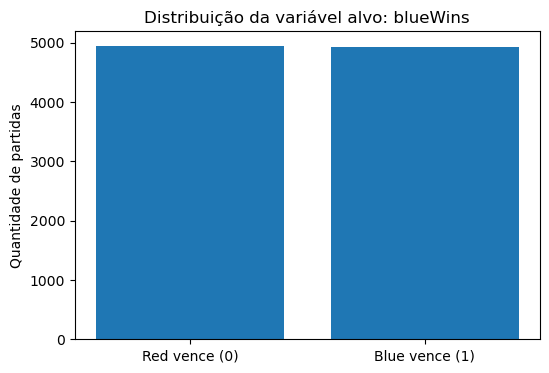

In [7]:
# Distribuição da variável alvo
contagem_alvo = df["blueWins"].value_counts().sort_index()
percentual_alvo = df["blueWins"].value_counts(normalize=True).sort_index() * 100

print("Contagem:")
print(contagem_alvo)
print("Percentual:")
print(percentual_alvo.round(2))

plt.figure(figsize=(6,4))
plt.bar(["Red vence (0)", "Blue vence (1)"], contagem_alvo.values)
plt.title("Distribuição da variável alvo: blueWins")
plt.ylabel("Quantidade de partidas")
plt.show()

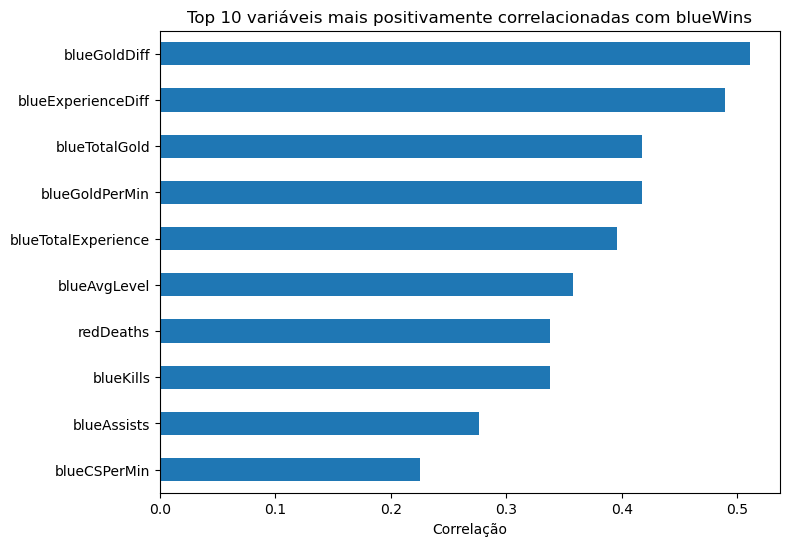

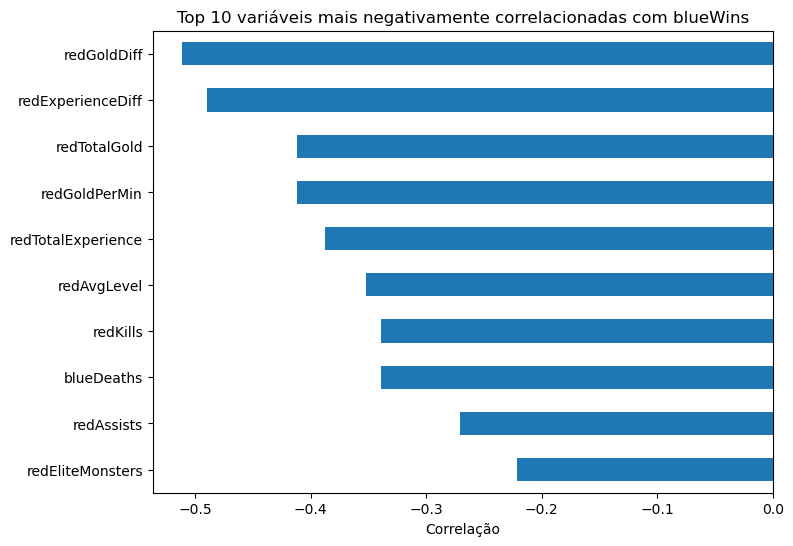

In [8]:
# Correlação das variáveis com a vitória do time azul
correlacoes = df.corr(numeric_only=True)["blueWins"].drop("blueWins").sort_values(ascending=False)

plt.figure(figsize=(8,6))
correlacoes.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 variáveis mais positivamente correlacionadas com blueWins")
plt.xlabel("Correlação")
plt.show()

plt.figure(figsize=(8,6))
correlacoes.tail(10).plot(kind="barh")
plt.title("Top 10 variáveis mais negativamente correlacionadas com blueWins")
plt.xlabel("Correlação")
plt.show()

## Visualizações adicionais da EDA

Além da distribuição do alvo e da correlação, serão usados histogramas, boxplots e heatmap para identificar distribuição das variáveis, possíveis outliers e relações entre atributos.


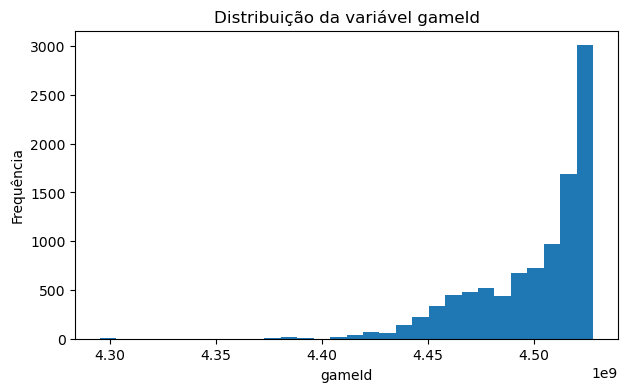

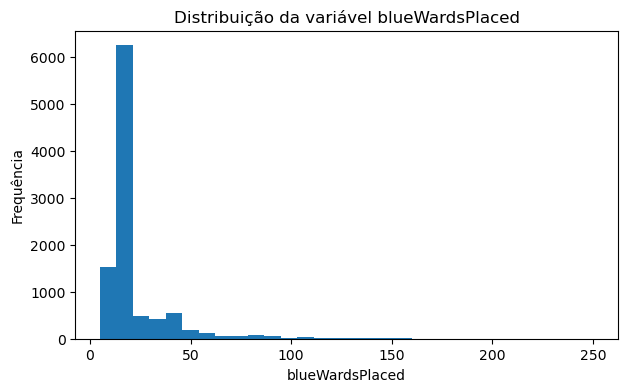

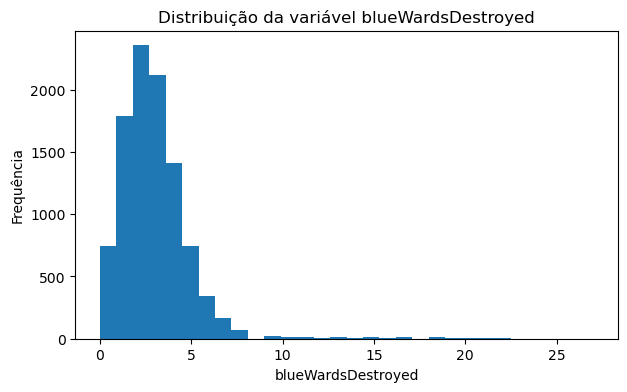

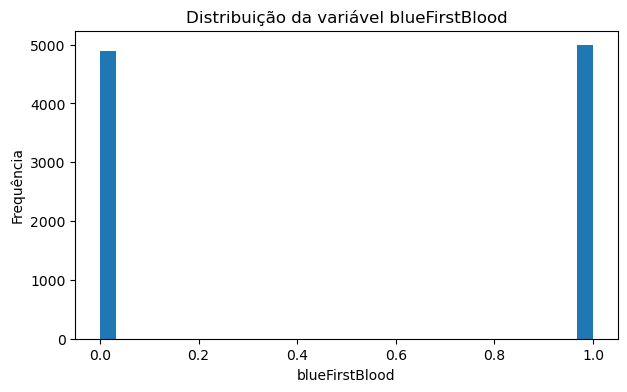

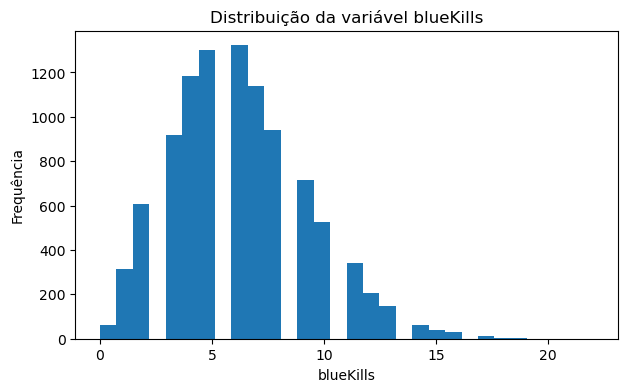

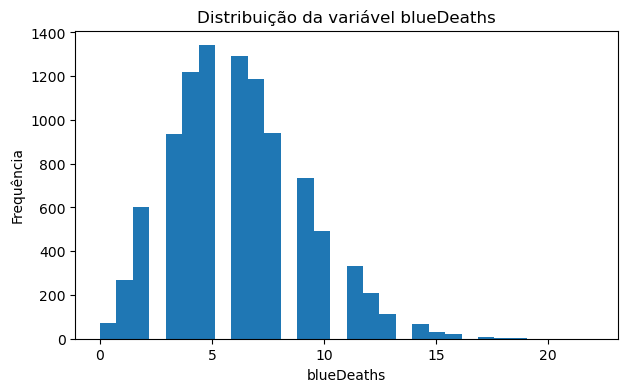

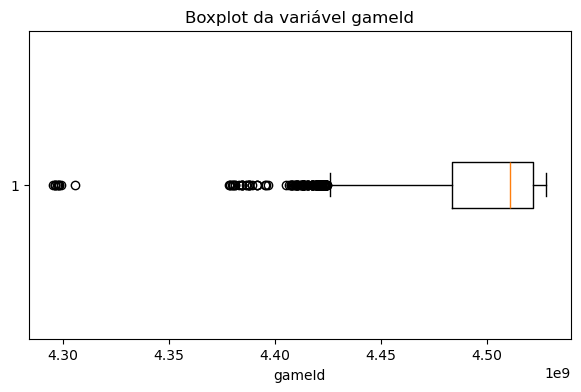

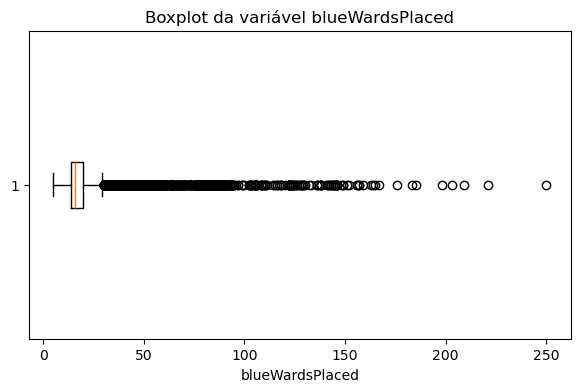

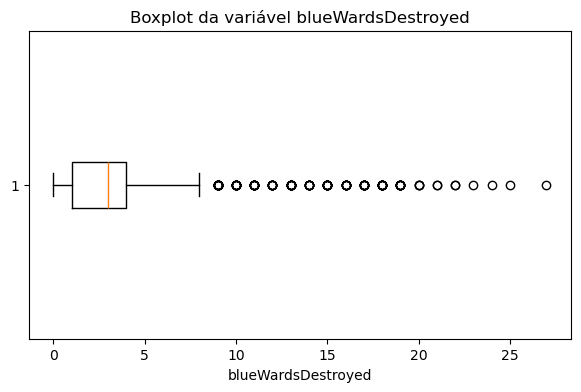

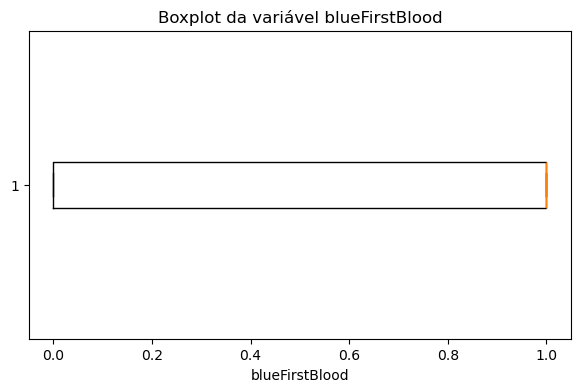

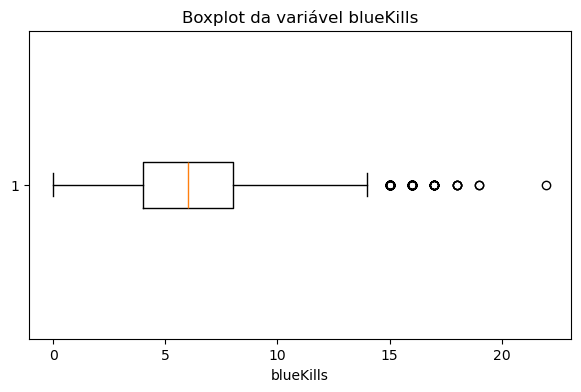

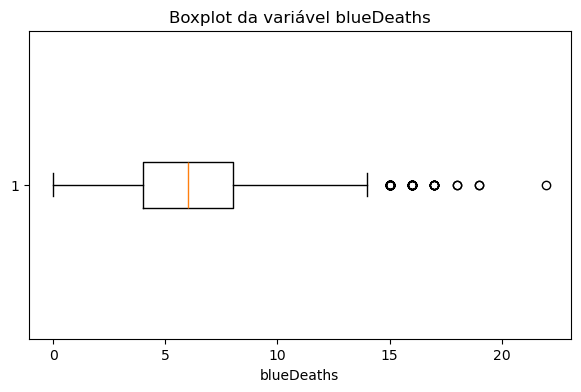

In [9]:
# Histogramas e boxplots para observar distribuição e possíveis outliers
variaveis_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variaveis_para_visualizar = [col for col in variaveis_numericas if col != "blueWins"][:12]

for coluna in variaveis_para_visualizar[:6]:
    plt.figure(figsize=(7, 4))
    plt.hist(df[coluna].dropna(), bins=30)
    plt.title(f"Distribuição da variável {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.show()

for coluna in variaveis_para_visualizar[:6]:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[coluna].dropna(), vert=False)
    plt.title(f"Boxplot da variável {coluna}")
    plt.xlabel(coluna)
    plt.show()


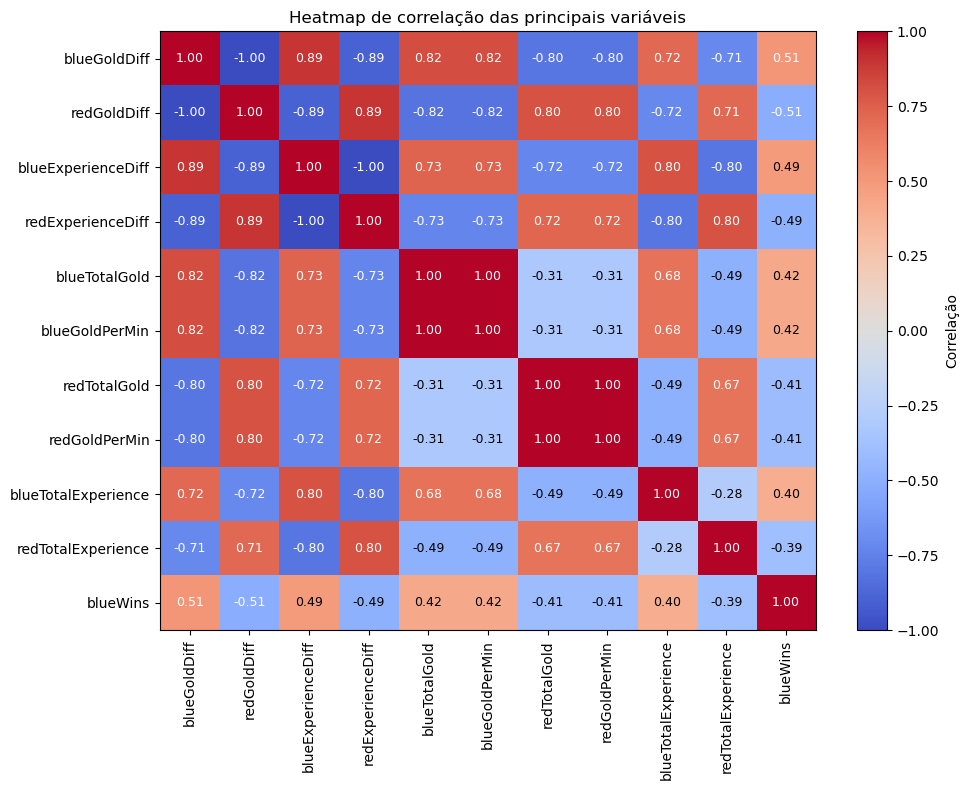

,blueGoldDiff,redGoldDiff,blueExperienceDiff,redExperienceDiff,blueTotalGold,blueGoldPerMin,redTotalGold,redGoldPerMin,blueTotalExperience,redTotalExperience,blueWins
blueGoldDiff,1.000000,-1.000000,0.894729,-0.894729,0.816803,0.816803,-0.804347,-0.804347,0.717968,-0.714405,0.511119
redGoldDiff,-1.000000,1.000000,-0.894729,0.894729,-0.816803,-0.816803,0.804347,0.804347,-0.717968,0.714405,-0.511119
blueExperienceDiff,0.894729,-0.894729,1.000000,-1.000000,0.729345,0.729345,-0.721190,-0.721190,0.800815,-0.800089,0.489558
redExperienceDiff,-0.894729,0.894729,-1.000000,1.000000,-0.729345,-0.729345,0.721190,0.721190,-0.800815,0.800089,-0.489558
blueTotalGold,0.816803,-0.816803,0.729345,-0.729345,1.000000,1.000000,-0.314212,-0.314212,0.676193,-0.491268,0.417213
blueGoldPerMin,0.816803,-0.816803,0.729345,-0.729345,1.000000,1.000000,-0.314212,-0.314212,0.676193,-0.491268,0.417213
redTotalGold,-0.804347,0.804347,-0.721190,0.721190,-0.314212,-0.314212,1.000000,1.000000,-0.485059,0.669646,-0.411396
redGoldPerMin,-0.804347,0.804347,-0.721190,0.721190,-0.314212,-0.314212,1.000000,1.000000,-0.485059,0.669646,-0.411396
blueTotalExperience,0.717968,-0.717968,0.800815,-0.800815,0.676193,0.676193,-0.485059,-0.485059,1.000000,-0.281446,0.396141
redTotalExperience,-0.714405,0.714405,-0.800089,0.800089,-0.491268,-0.491268,0.669646,0.669646,-0.281446,1.000000,-0.387588


In [11]:
# Heatmap de correlação das variáveis mais associadas ao alvo
principais_variaveis = correlacoes.abs().sort_values(ascending=False).head(10).index.tolist()
matriz_corr = df[principais_variaveis + ["blueWins"]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(matriz_corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlação")

plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=90)
plt.yticks(range(len(matriz_corr.index)), matriz_corr.index)

# Adiciona os valores dentro das células
for i in range(len(matriz_corr.index)):
    for j in range(len(matriz_corr.columns)):
        plt.text(
            j,
            i,
            f"{matriz_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if abs(matriz_corr.iloc[i, j]) > 0.5 else "black",
            fontsize=9
        )

plt.title("Heatmap de correlação das principais variáveis")
plt.tight_layout()
plt.show()

display(matriz_corr)


## Análise estatística simples

Para reforçar a análise exploratória, comparamos a média das principais variáveis entre partidas em que o time azul venceu e partidas em que perdeu.


In [12]:
# Comparação estatística simples entre as classes
analise_classes = []
for coluna in principais_variaveis:
    media_derrota = df.loc[df["blueWins"] == 0, coluna].mean()
    media_vitoria = df.loc[df["blueWins"] == 1, coluna].mean()
    diferenca = media_vitoria - media_derrota
    analise_classes.append({
        "Variável": coluna,
        "Média quando Blue perde": media_derrota,
        "Média quando Blue vence": media_vitoria,
        "Diferença média": diferenca,
        "Diferença absoluta": abs(diferenca)
    })
analise_classes = pd.DataFrame(analise_classes).sort_values("Diferença absoluta", ascending=False)
display(analise_classes)


,Variável,Média quando Blue perde,Média quando Blue vence,Diferença média,Diferença absoluta
0,blueGoldDiff,-1237.066680,1270.718053,2507.784733,2507.784733
1,redGoldDiff,1237.066680,-1270.718053,-2507.784733,2507.784733
2,blueExperienceDiff,-971.898969,908.274442,1880.173412,1880.173412
3,redExperienceDiff,971.898969,-908.274442,-1880.173412,1880.173412
4,blueTotalGold,15864.111134,17145.263895,1281.152761,1281.152761
6,redTotalGold,17101.177814,15874.545842,-1226.631972,1226.631972
8,blueTotalExperience,17453.471610,18404.577890,951.106280,951.106280
9,redTotalExperience,18425.370580,17496.303448,-929.067132,929.067132
5,blueGoldPerMin,1586.411113,1714.526389,128.115276,128.115276
7,redGoldPerMin,1710.117781,1587.454584,-122.663197,122.663197


## Preparação dos dados e redução de redundância

A coluna `gameId` é apenas um identificador da partida, por isso será removida.

Além disso, muitas variáveis aparecem em pares espelhados entre os times, por exemplo `blueGoldDiff`/`redGoldDiff` ou `blueKills`/`redKills`. Para reduzir redundância, o projeto cria variáveis de diferença no formato:

`diff_variavel = variável_blue - variável_red`

Depois disso, as colunas originais espelhadas são removidas. Assim o modelo aprende a vantagem relativa entre os times, com menos colunas repetidas.


In [13]:
# Separação entre variáveis explicativas e alvo com redução de redundância blue/red

# Cópia da base para modelagem
df_modelo = df.copy()

# Remove identificador da partida, se existir
if "gameId" in df_modelo.columns:
    df_modelo = df_modelo.drop(columns=["gameId"])

# Cria variáveis de diferença para pares blue/red e remove colunas espelhadas
colunas_blue_red_remover = []
novas_features_diff = []

for coluna_blue in df_modelo.columns:
    if coluna_blue.startswith("blue") and coluna_blue != "blueWins":
        sufixo = coluna_blue.replace("blue", "", 1)
        coluna_red = "red" + sufixo
        
        if coluna_red in df_modelo.columns:
            nome_diff = "diff" + sufixo
            df_modelo[nome_diff] = df_modelo[coluna_blue] - df_modelo[coluna_red]
            novas_features_diff.append(nome_diff)
            colunas_blue_red_remover.extend([coluna_blue, coluna_red])

# Remove apenas colunas existentes e evita duplicidade na lista
colunas_blue_red_remover = sorted(set(colunas_blue_red_remover))
df_modelo = df_modelo.drop(columns=colunas_blue_red_remover)

print("Quantidade de variáveis blue/red removidas:", len(colunas_blue_red_remover))
print("Quantidade de novas variáveis de diferença criadas:", len(novas_features_diff))
print("Novas variáveis criadas:", novas_features_diff[:10])
print("Formato final da base para modelagem:", df_modelo.shape)

# Separação entre X e y
X = df_modelo.drop(columns=["blueWins"])
y = df_modelo["blueWins"]

x_treino, x_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", x_treino.shape)
print("Teste:", x_teste.shape)


Quantidade de variáveis blue/red removidas: 38
Quantidade de novas variáveis de diferença criadas: 19
Novas variáveis criadas: ['diffWardsPlaced', 'diffWardsDestroyed', 'diffFirstBlood', 'diffKills', 'diffDeaths', 'diffAssists', 'diffEliteMonsters', 'diffDragons', 'diffHeralds', 'diffTowersDestroyed']
Formato final da base para modelagem: (9879, 20)
Treino: (7903, 19)
Teste: (1976, 19)


### Tratamento de valores faltantes e checagem final da modelagem

Caso existam valores faltantes após a preparação, eles serão tratados pela mediana das variáveis numéricas. Isso evita falhas no treinamento e mantém o notebook executável.


In [14]:
# Tratamento seguro de valores faltantes na base de modelagem
if X.isna().sum().sum() > 0:
    X = X.fillna(X.median(numeric_only=True))
    x_treino, x_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

print("Total de nulos em X:", X.isna().sum().sum())
print("Distribuição do alvo no treino:")
print(y_treino.value_counts(normalize=True).round(3))
print("Distribuição do alvo no teste:")
print(y_teste.value_counts(normalize=True).round(3))


Total de nulos em X: 0
Distribuição do alvo no treino:
blueWins
0    0.501
1    0.499
Name: proportion, dtype: float64
Distribuição do alvo no teste:
blueWins
0    0.501
1    0.499
Name: proportion, dtype: float64


## Criação dos modelos de classificação

O modelo principal de referência será a **Regressão Logística**, porque é simples, interpretável e muito usada como baseline em problemas de classificação.

Também serão testados:

- Naive Bayes;
- Árvore de Decisão;
- Random Forest;
- Gradient Boosting;
- XGBoost;
- Ensemble com Voting Classifier.


In [15]:
# Modelos base e modelos avançados
modelo_regressao_logistica = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_naive_bayes = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", GaussianNB())
])

modelo_arvore = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

modelo_gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

modelo_ensemble = VotingClassifier(
    estimators=[
        ("regressao_logistica", modelo_regressao_logistica),
        ("arvore", modelo_arvore),
        ("random_forest", modelo_random_forest),
        ("gradient_boosting", modelo_gradient_boosting)
    ],
    voting="soft"
)

modelos = {
    "Regressão Logística": modelo_regressao_logistica,
    "Naive Bayes": modelo_naive_bayes,
    "Árvore de Decisão": modelo_arvore,
    "Random Forest": modelo_random_forest,
    "Gradient Boosting": modelo_gradient_boosting,
    "Ensemble Voting": modelo_ensemble
}


modelo_xgboost = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
 )
modelos["XGBoost"] = modelo_xgboost

## Treinamento e avaliação dos modelos

As métricas usadas serão:

- **Acurácia:** percentual geral de acertos;
- **Precisão:** entre as previsões de vitória do time azul, quantas estavam corretas;
- **Recall:** entre as vitórias reais do time azul, quantas o modelo encontrou;
- **F1-score:** equilíbrio entre precisão e recall;
- **AUC:** capacidade do modelo separar vitória e derrota.

In [16]:
# Treinamento e avaliação
resultados = []
probabilidades = {}
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(x_treino, y_treino)
    y_pred = modelo.predict(x_teste)
    y_proba = modelo.predict_proba(x_teste)[:, 1]
    
    previsoes[nome] = y_pred
    probabilidades[nome] = y_proba
    
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_teste, y_pred),
        "Precisão": precision_score(y_teste, y_pred),
        "Recall": recall_score(y_teste, y_pred),
        "F1-score": f1_score(y_teste, y_pred),
        "AUC": roc_auc_score(y_teste, y_proba)
    })

resultado_modelos = pd.DataFrame(resultados).sort_values(by="AUC", ascending=False)
resultado_modelos

,Modelo,Acurácia,Precisão,Recall,F1-score,AUC
0,Regressão Logística,0.714069,0.711133,0.719067,0.715078,0.806600
5,Ensemble Voting,0.715587,0.717213,0.709939,0.713558,0.806092
1,Naive Bayes,0.719130,0.719227,0.717039,0.718131,0.804254
4,Gradient Boosting,0.714069,0.714140,0.711968,0.713052,0.803378
6,XGBoost,0.712045,0.714727,0.703854,0.709249,0.800814
2,Árvore de Decisão,0.719130,0.732973,0.687627,0.709576,0.799201
3,Random Forest,0.707490,0.706897,0.706897,0.706897,0.794533


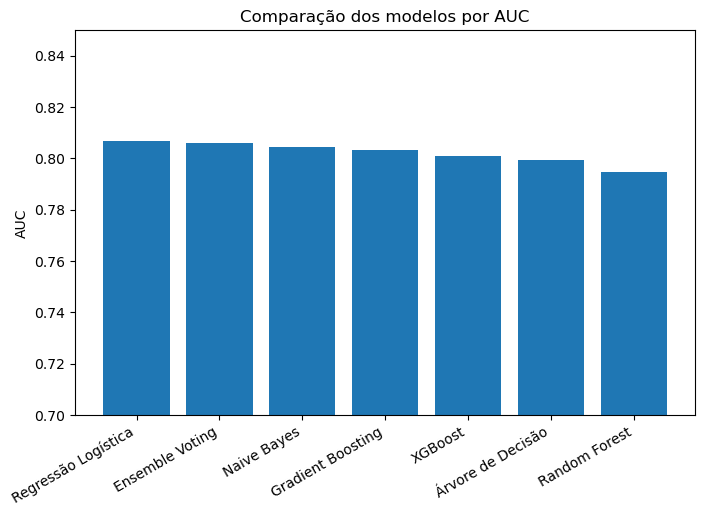

In [17]:
# Gráfico comparando AUC dos modelos
plt.figure(figsize=(8,5))
plt.bar(resultado_modelos["Modelo"], resultado_modelos["AUC"])
plt.title("Comparação dos modelos por AUC")
plt.ylabel("AUC")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.70, 0.85)
plt.show()

## Curva ROC e AUC

A curva ROC mostra a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos. Quanto maior a AUC, melhor a separação entre vitória e derrota.

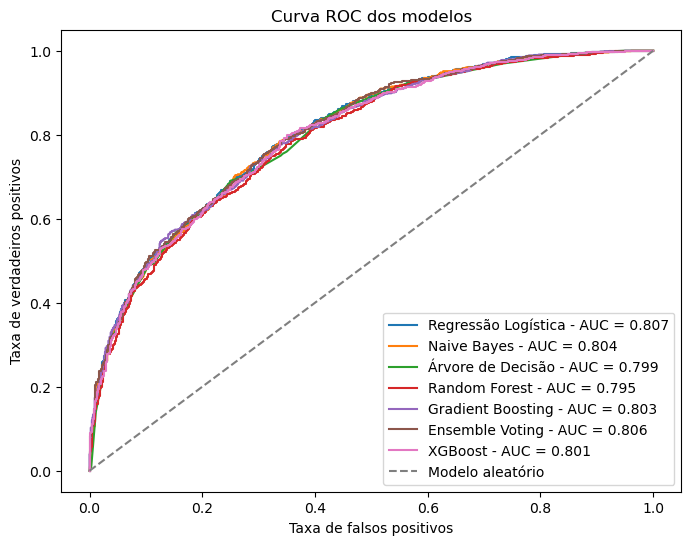

In [18]:
# Curva ROC
plt.figure(figsize=(8,6))

for nome in modelos.keys():
    fpr, tpr, thresholds = roc_curve(y_teste, probabilidades[nome])
    auc = roc_auc_score(y_teste, probabilidades[nome])
    plt.plot(fpr, tpr, label=f"{nome} - AUC = {auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatório")
plt.title("Curva ROC dos modelos")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()
plt.show()

## Validação Cruzada

A validação cruzada ajuda a verificar se o modelo mantém bom desempenho em diferentes divisões da base de dados. Aqui será usada a métrica **ROC AUC**.

In [19]:
# Validação Cruzada com ROC AUC

vc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_vc = []

for nome, modelo in modelos.items():
    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=vc,
        scoring="roc_auc"
    )
    
    resultados_vc.append({
        "Modelo": nome,
        "AUC médio VC": scores.mean(),
        "Desvio padrão VC": scores.std(),
        "Scores": scores
    })

resultado_vc = pd.DataFrame(resultados_vc).sort_values(by="AUC médio VC", ascending=False)
resultado_vc[["Modelo", "AUC médio VC", "Desvio padrão VC"]]

,Modelo,AUC médio VC,Desvio padrão VC
0,Regressão Logística,0.810580,0.012294
5,Ensemble Voting,0.807293,0.012276
1,Naive Bayes,0.806940,0.010280
4,Gradient Boosting,0.805609,0.012644
6,XGBoost,0.802095,0.011308
3,Random Forest,0.796904,0.012357
2,Árvore de Decisão,0.795317,0.010671


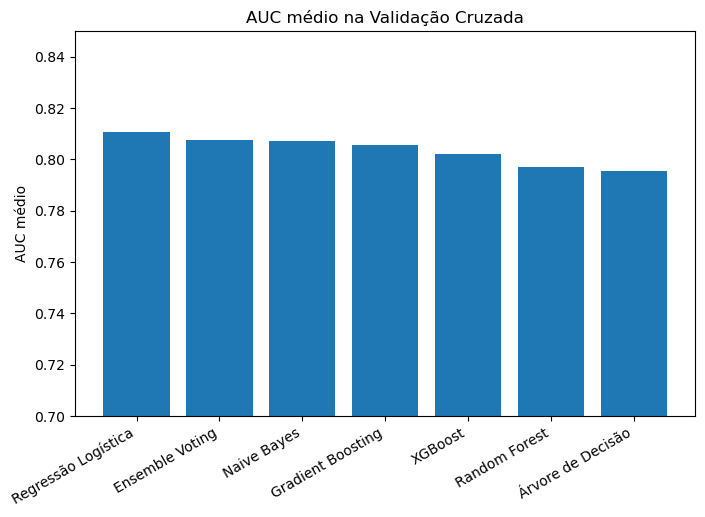

In [20]:
# Visualizando validação cruzada
plt.figure(figsize=(8,5))
plt.bar(resultado_vc["Modelo"], resultado_vc["AUC médio VC"])
plt.title("AUC médio na Validação Cruzada")
plt.ylabel("AUC médio")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.70, 0.85)
plt.show()

## Ajuste de hiperparâmetros com RandomizedSearchCV

Depois de testar os modelos principais, o próximo passo é melhorar o desempenho de um modelo forte. Aqui será usado o `RandomizedSearchCV` no **Gradient Boosting**, com validação cruzada e métrica `roc_auc`.

Esse ajuste ajuda a encontrar uma combinação melhor de hiperparâmetros sem testar todas as possibilidades, tornando o processo mais rápido do que um `GridSearchCV` completo.


In [21]:
# Ajuste de hiperparâmetros no Gradient Boosting
parametros_gb = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

busca_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=parametros_gb,
    n_iter=20,
    scoring="roc_auc",
    cv=vc,
    random_state=42,
    n_jobs=-1
)

busca_gb.fit(x_treino, y_treino)

print("Melhores hiperparâmetros encontrados:")
print(busca_gb.best_params_)
print("Melhor AUC médio na validação cruzada:", round(busca_gb.best_score_, 4))

modelo_gb_tunado = busca_gb.best_estimator_


Melhores hiperparâmetros encontrados:
{'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.05}
Melhor AUC médio na validação cruzada: 0.8092


In [27]:
# modelo tunado
y_pred_tunado = modelo_gb_tunado.predict(x_teste)
y_proba_tunado = modelo_gb_tunado.predict_proba(x_teste)[:, 1]

resultado_tunado = pd.DataFrame([{
    "Modelo": "Gradient Boosting Tunado",
    "Acurácia": accuracy_score(y_teste, y_pred_tunado),
    "Precisão": precision_score(y_teste, y_pred_tunado),
    "Recall": recall_score(y_teste, y_pred_tunado),
    "F1-score": f1_score(y_teste, y_pred_tunado),
    "AUC": roc_auc_score(y_teste, y_proba_tunado)
}])

In [28]:
# Avaliação do modelo tunado
resultado_modelos_final = pd.concat(
    [resultado_modelos, resultado_tunado],
    ignore_index=True
).sort_values(by="AUC", ascending=False)

In [30]:
# Resultado dos modelos:
display(resultado_modelos_final)

,Modelo,Acurácia,Precisão,Recall,F1-score,AUC
0,Regressão Logística,0.714069,0.711133,0.719067,0.715078,0.806600
7,Gradient Boosting Tunado,0.719636,0.718623,0.720081,0.719352,0.806383
1,Ensemble Voting,0.715587,0.717213,0.709939,0.713558,0.806092
2,Naive Bayes,0.719130,0.719227,0.717039,0.718131,0.804254
3,Gradient Boosting,0.714069,0.714140,0.711968,0.713052,0.803378
4,XGBoost,0.712045,0.714727,0.703854,0.709249,0.800814
5,Árvore de Decisão,0.719130,0.732973,0.687627,0.709576,0.799201
6,Random Forest,0.707490,0.706897,0.706897,0.706897,0.794533


In [31]:
# Relatório Final
melhor = resultado_modelos_final.iloc[0]

print("="*70)
print(" RELATÓRIO FINAL DE AVALIAÇÃO DOS MODELOS ".center(70))
print("="*70)

for _, linha in resultado_modelos_final.iterrows():
    print(f"\nModelo: {linha['Modelo']}")
    print("-"*50)
    print(f"Acurácia : {linha['Acurácia']:.4f}")
    print(f"Precisão : {linha['Precisão']:.4f}")
    print(f"Recall   : {linha['Recall']:.4f}")
    print(f"F1-Score : {linha['F1-score']:.4f}")
    print(f"AUC      : {linha['AUC']:.4f}")

print("\n" + "="*70)
print(" MELHOR MODELO ".center(70))
print("="*70)
print(f"Modelo escolhido: {melhor['Modelo']}")
print(f"AUC: {melhor['AUC']:.4f}")
print(f"F1-Score: {melhor['F1-score']:.4f}")
print(f"Acurácia: {melhor['Acurácia']:.4f}")

               RELATÓRIO FINAL DE AVALIAÇÃO DOS MODELOS               

Modelo: Regressão Logística
--------------------------------------------------
Acurácia : 0.7141
Precisão : 0.7111
Recall   : 0.7191
F1-Score : 0.7151
AUC      : 0.8066

Modelo: Gradient Boosting Tunado
--------------------------------------------------
Acurácia : 0.7196
Precisão : 0.7186
Recall   : 0.7201
F1-Score : 0.7194
AUC      : 0.8064

Modelo: Ensemble Voting
--------------------------------------------------
Acurácia : 0.7156
Precisão : 0.7172
Recall   : 0.7099
F1-Score : 0.7136
AUC      : 0.8061

Modelo: Naive Bayes
--------------------------------------------------
Acurácia : 0.7191
Precisão : 0.7192
Recall   : 0.7170
F1-Score : 0.7181
AUC      : 0.8043

Modelo: Gradient Boosting
--------------------------------------------------
Acurácia : 0.7141
Precisão : 0.7141
Recall   : 0.7120
F1-Score : 0.7131
AUC      : 0.8034

Modelo: XGBoost
--------------------------------------------------
Acurácia : 0.7120
Pr

## Comparação final e justificativa da escolha

O melhor modelo será escolhido priorizando AUC, pois ela mede a capacidade de separação entre vitória e derrota. Também serão observados F1-score, precisão e recall para garantir equilíbrio entre os erros.


In [32]:
# Tabela final organizada e arredondada para apresentação
resultado_apresentacao = resultado_modelos_final.copy()
metricas = ["Acurácia", "Precisão", "Recall", "F1-score", "AUC"]
resultado_apresentacao[metricas] = resultado_apresentacao[metricas].round(4)
display(resultado_apresentacao)

melhor_nome_preliminar = resultado_modelos_final.iloc[0]["Modelo"]
print(f"Modelo recomendado até aqui: {melhor_nome_preliminar}")


,Modelo,Acurácia,Precisão,Recall,F1-score,AUC
0,Regressão Logística,0.7141,0.7111,0.7191,0.7151,0.8066
7,Gradient Boosting Tunado,0.7196,0.7186,0.7201,0.7194,0.8064
1,Ensemble Voting,0.7156,0.7172,0.7099,0.7136,0.8061
2,Naive Bayes,0.7191,0.7192,0.7170,0.7181,0.8043
3,Gradient Boosting,0.7141,0.7141,0.7120,0.7131,0.8034
4,XGBoost,0.7120,0.7147,0.7039,0.7092,0.8008
5,Árvore de Decisão,0.7191,0.7330,0.6876,0.7096,0.7992
6,Random Forest,0.7075,0.7069,0.7069,0.7069,0.7945


Modelo recomendado até aqui: Regressão Logística


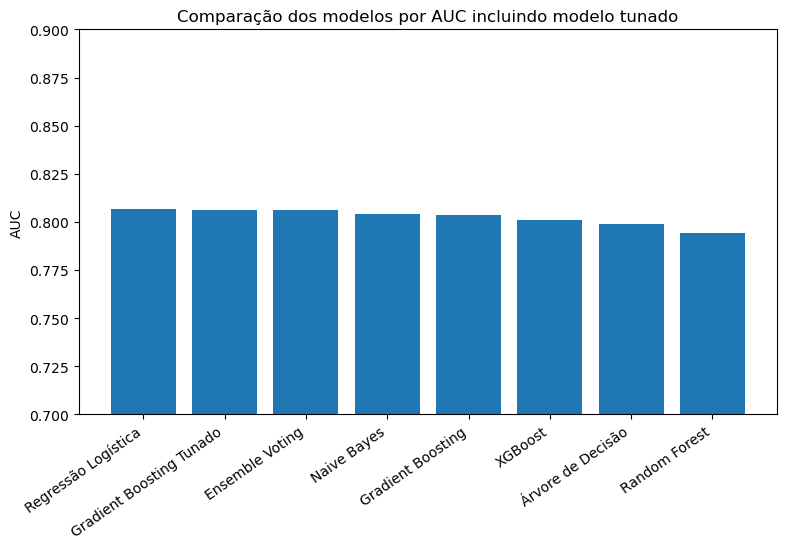

In [33]:
# Atualiza o dicionário de modelos com o modelo tunado
modelos["Gradient Boosting Tunado"] = modelo_gb_tunado
previsoes["Gradient Boosting Tunado"] = y_pred_tunado
probabilidades["Gradient Boosting Tunado"] = y_proba_tunado

# Novo gráfico de comparação incluindo o modelo tunado
plt.figure(figsize=(9,5))
plt.bar(resultado_modelos_final["Modelo"], resultado_modelos_final["AUC"])
plt.title("Comparação dos modelos por AUC incluindo modelo tunado")
plt.ylabel("AUC")
plt.xticks(rotation=35, ha="right")
plt.ylim(0.70, 0.90)
plt.show()


## Matriz de confusão do melhor modelo

Vamos selecionar automaticamente o modelo com maior AUC no conjunto de teste.

Melhor modelo pelo AUC no teste: Regressão Logística
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71       990
           1       0.71      0.72      0.72       986

    accuracy                           0.71      1976
   macro avg       0.71      0.71      0.71      1976
weighted avg       0.71      0.71      0.71      1976



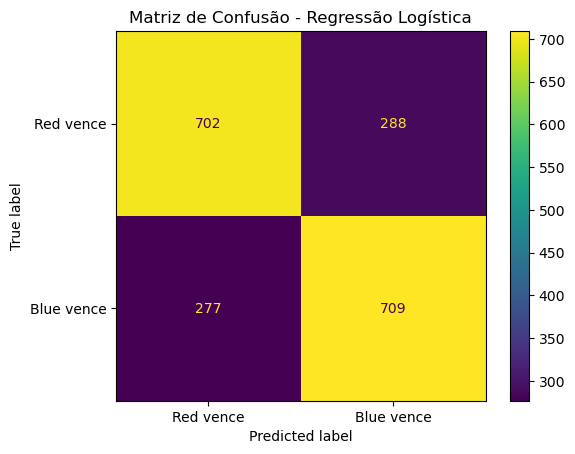

In [34]:
# Melhor modelo e matriz de confusão

# Usa a tabela final, que inclui o modelo tunado
melhor_nome = resultado_modelos_final.iloc[0]["Modelo"]
melhor_modelo = modelos[melhor_nome]
melhor_pred = previsoes[melhor_nome]

print("Melhor modelo pelo AUC no teste:", melhor_nome)
print("Relatório de classificação:")
print(classification_report(y_teste, melhor_pred))

cm = confusion_matrix(y_teste, melhor_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Red vence", "Blue vence"])
disp.plot(values_format="d")
plt.title(f"Matriz de Confusão - {melhor_nome}")
plt.show()


## Validação final com dados não vistos

O conjunto de teste foi separado antes do treinamento e não foi usado no ajuste dos modelos. Por isso, ele representa a validação final com dados não vistos, conforme solicitado no roteiro do projeto.


In [35]:
# Métricas finais do melhor modelo em dados não vistos
melhor_proba = probabilidades[melhor_nome]
metricas_finais = {
    "Modelo final": melhor_nome,
    "Acurácia teste": accuracy_score(y_teste, melhor_pred),
    "Precisão teste": precision_score(y_teste, melhor_pred),
    "Recall teste": recall_score(y_teste, melhor_pred),
    "F1-score teste": f1_score(y_teste, melhor_pred),
    "AUC teste": roc_auc_score(y_teste, melhor_proba),
    "Log Loss teste": log_loss(y_teste, melhor_proba)
}
display(pd.DataFrame([metricas_finais]).round(4))


,Modelo final,Acurácia teste,Precisão teste,Recall teste,F1-score teste,AUC teste,Log Loss teste
0,Regressão Logística,0.7141,0.7111,0.7191,0.7151,0.8066,0.5312


## Interpretação do modelo principal: Regressão Logística

Como a Regressão Logística é interpretável, podemos observar quais variáveis mais influenciaram a previsão de vitória do time azul.

In [36]:
# Coeficientes da Regressão Logística


modelo_regressao_logistica.fit(x_treino, y_treino)
coeficientes = modelo_regressao_logistica.named_steps["modelo"].coef_[0]

importancia_lr = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": coeficientes,
    "Impacto_abs": np.abs(coeficientes)
}).sort_values(by="Impacto_abs", ascending=False)

importancia_lr.head(15)

,Variável,Coeficiente,Impacto_abs
18,diffGoldPerMin,0.437343,0.437343
10,diffTotalGold,0.437343,0.437343
15,diffGoldDiff,0.437343,0.437343
16,diffExperienceDiff,0.226728,0.226728
12,diffTotalExperience,0.226728,0.226728
7,diffDragons,0.185674,0.185674
6,diffEliteMonsters,0.123892,0.123892
5,diffAssists,-0.097750,0.097750
9,diffTowersDestroyed,-0.090961,0.090961
13,diffTotalMinionsKilled,-0.083073,0.083073


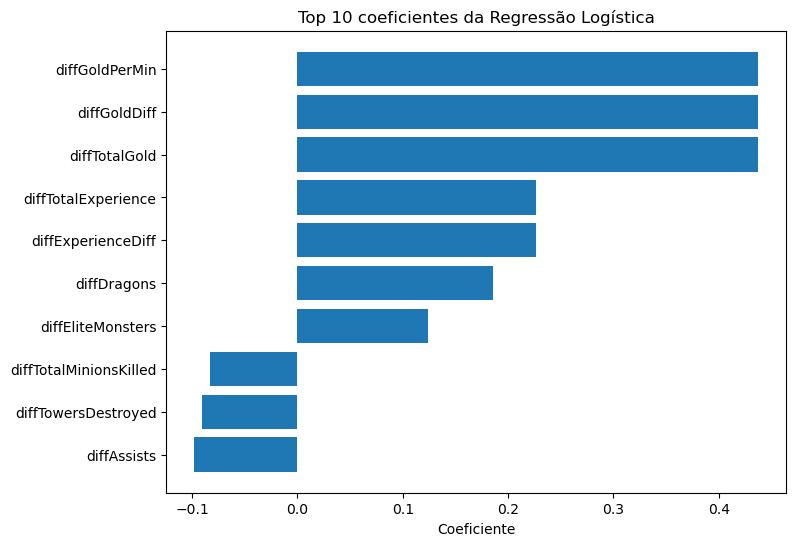

In [37]:
# Gráfico das variáveis mais importantes na Regressão Logística
plt.figure(figsize=(8,6))
top_coef = importancia_lr.head(10).sort_values(by="Coeficiente")
plt.barh(top_coef["Variável"], top_coef["Coeficiente"])
plt.title("Top 10 coeficientes da Regressão Logística")
plt.xlabel("Coeficiente")
plt.show()

# Conclusão

Este projeto teve como objetivo desenvolver um modelo de Machine Learning capaz de prever a vitória do time azul em partidas ranqueadas de *League of Legends* a partir de informações coletadas nos primeiros minutos da partida.

Ao longo do desenvolvimento foram realizadas todas as etapas de um projeto de Ciência de Dados: compreensão do problema, análise exploratória dos dados (EDA), tratamento e preparação da base, engenharia de atributos por meio da criação das variáveis de diferença (`diff`), treinamento de diferentes algoritmos de classificação, validação cruzada, ajuste de hiperparâmetros utilizando **RandomizedSearchCV** e avaliação dos modelos por meio das métricas **Acurácia, Precisão, Recall, F1-Score, AUC-ROC** e **Log Loss**.

A comparação entre os modelos mostrou que algoritmos baseados em *Ensemble Learning*, especialmente o **Gradient Boosting Tunado**, apresentaram o melhor desempenho na tarefa de classificação, demonstrando elevada capacidade de distinguir partidas em que o time azul venceria daquelas em que seria derrotado. A utilização da métrica **AUC-ROC** como principal critério de seleção permitiu escolher um modelo mais robusto e menos dependente de um limiar específico de classificação.

Além da construção do modelo preditivo, a análise exploratória permitiu identificar que as diferenças de ouro, experiência, abates, estruturas destruídas e controle de objetivos entre as equipes possuem forte influência no resultado final da partida, evidenciando que pequenas vantagens acumuladas durante o início do jogo aumentam significativamente a probabilidade de vitória.

Como limitações, este trabalho utiliza apenas uma base histórica específica e considera informações disponíveis nos primeiros minutos da partida. Dessa forma, o modelo pode apresentar redução de desempenho quando aplicado a partidas de outras temporadas, diferentes patches do jogo ou cenários competitivos distintos.

Como trabalhos futuros, recomenda-se:

* Avaliar algoritmos ainda mais robustos, como XGBoost, LightGBM e CatBoost;
* Aplicar técnicas de explicabilidade de modelos, como SHAP e LIME, para interpretar individualmente cada previsão;
* Implementar otimização automática de hiperparâmetros utilizando Optuna;
* Desenvolver uma aplicação web com Streamlit para disponibilizar previsões em tempo real;
* Criar um pipeline completo de deploy utilizando Docker e serviços em nuvem.

De forma geral, o projeto demonstra a aplicação prática do processo de Ciência de Dados de ponta a ponta, desde a preparação dos dados até a seleção do modelo final, evidenciando conhecimentos em análise exploratória, engenharia de atributos, modelagem preditiva, avaliação estatística e boas práticas de desenvolvimento. O resultado obtido mostra que técnicas de Machine Learning podem fornecer previsões confiáveis para partidas de *League of Legends*, tornando este projeto uma excelente demonstração de competências para aplicações acadêmicas e para composição de um portfólio profissional.


### O que os resultados significam?
O modelo final foi a Regressão Logística, alcançando AUC de aproximadamente 0,81, demonstrando boa capacidade de distinguir partidas vencidas e perdidas pelo time azul. Em termos práticos, o modelo consegue identificar padrões relevantes dos primeiros minutos da partida para estimar o vencedor.

### Insights de negócio
- A vantagem de ouro é o principal indicador de vitória.
- Controle de dragões e objetivos do mapa aumenta significativamente as chances de vencer.
- Vantagem de experiência e ouro por minuto contribuem diretamente para o sucesso da equipe.
- O modelo pode apoiar análises estratégicas e estudos de desempenho de equipes.

# Visualizações

### Comparação dos modelos (AUC)

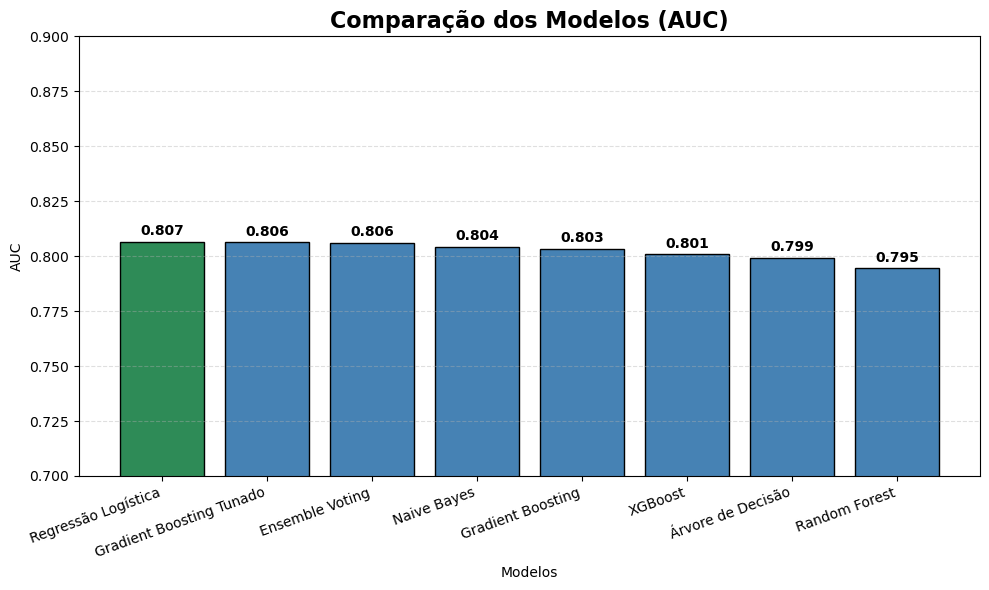

In [49]:
cores = [
    "seagreen" if auc == resultado_modelos_final["AUC"].max()
    else "steelblue"
    for auc in resultado_modelos_final["AUC"]
]

plt.figure(figsize=(10,6))

barras = plt.bar(
    resultado_modelos_final["Modelo"],
    resultado_modelos_final["AUC"],
    color=cores,
    edgecolor="black"
)

plt.title("Comparação dos Modelos (AUC)", fontsize=16, fontweight="bold")
plt.xlabel("Modelos")
plt.ylabel("AUC")
plt.ylim(0.70, 0.90)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Valor da AUC em cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.003,
        f"{altura:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**O gráfico compara o desempenho dos modelos testados utilizando a métrica AUC, que mede a capacidade de diferenciar corretamente partidas vencidas e perdidas. Quanto maior a AUC, melhor o desempenho do modelo. A comparação demonstra que o Gradient Boosting Tunado apresentou o melhor resultado, justificando sua escolha como modelo final do projeto.**

### Curva ROC

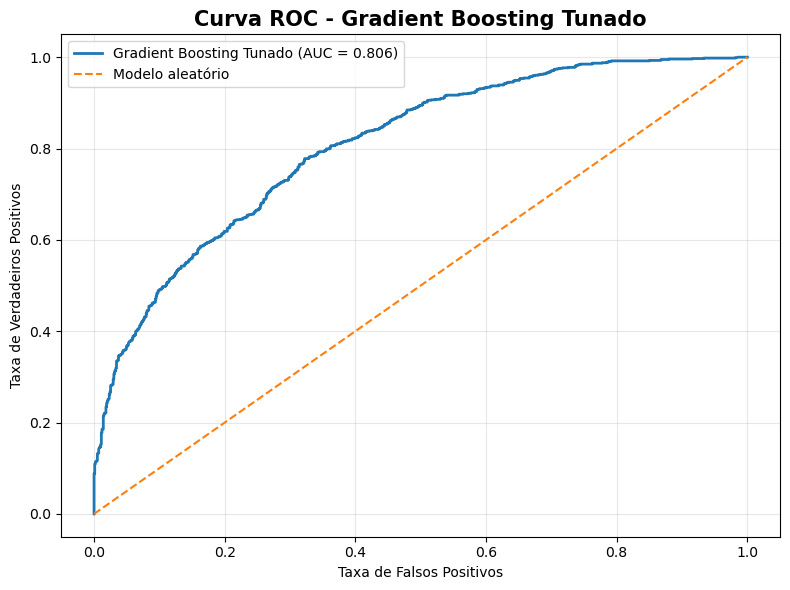

In [39]:
# Probabilidades do modelo
y_proba_tunado = modelo_gb_tunado.predict_proba(x_teste)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_teste, y_proba_tunado)
auc = roc_auc_score(y_teste, y_proba_tunado)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, linewidth=2, label=f"Gradient Boosting Tunado (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatório")

plt.title("Curva ROC - Gradient Boosting Tunado", fontsize=15, fontweight="bold")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**A Curva ROC demonstra a capacidade do modelo em distinguir vitórias de derrotas considerando diferentes limiares de decisão. Quanto mais próxima a curva estiver do canto superior esquerdo, melhor é o desempenho do modelo. O valor elevado da AUC confirma que o modelo possui excelente capacidade de classificação, sendo adequado para apoiar previsões de partidas.**

### Matriz de Confusão

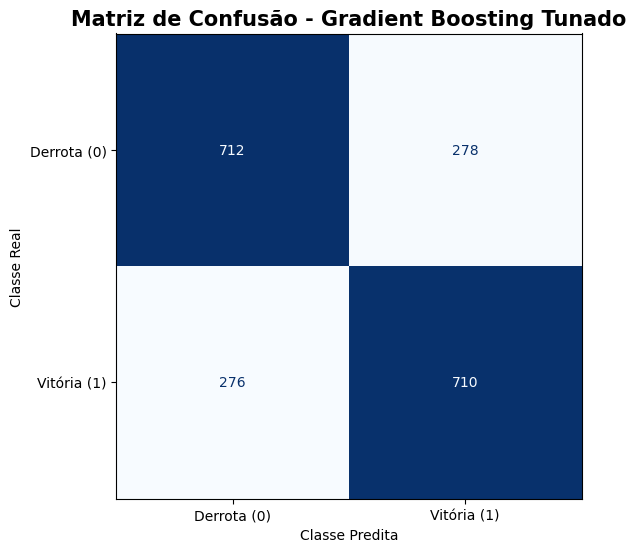

In [40]:
# Previsões do modelo
y_pred_tunado = modelo_gb_tunado.predict(x_teste)

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred_tunado)

# Exibição
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Derrota (0)", "Vitória (1)"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Gradient Boosting Tunado",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.grid(False)
plt.tight_layout()
plt.show()

**A matriz de confusão apresenta, de forma visual, os acertos e erros do modelo. Os valores na diagonal principal representam previsões corretas, enquanto os demais indicam erros de classificação. Como a maior parte das previsões concentra-se na diagonal, conclui-se que o modelo apresenta bom desempenho para identificar tanto vitórias quanto derrotas do time azul.**

### Como interpretar a matriz:

| Resultado                    | Significado                                      |
| ---------------------------- | ------------------------------------------------ |
| **Verdadeiro Negativo (TN)** | O modelo previu derrota e realmente foi derrota. |
| **Falso Positivo (FP)**      | O modelo previu vitória, mas ocorreu derrota.    |
| **Falso Negativo (FN)**      | O modelo previu derrota, mas ocorreu vitória.    |
| **Verdadeiro Positivo (TP)** | O modelo previu vitória e realmente foi vitória. |


### Importância das variáveis

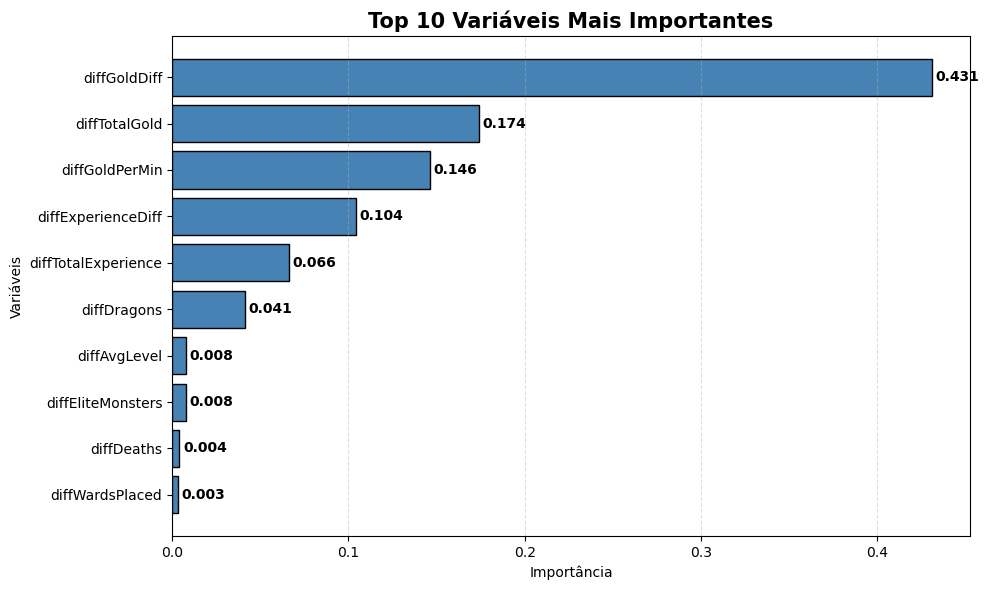

In [44]:
# Importância das variáveis
importancias = pd.Series(
    modelo_gb_tunado.feature_importances_,
    index=x_treino.columns
).sort_values(ascending=False)

# Top 10 variáveis
top10 = importancias.head(10)

plt.figure(figsize=(10, 6))

barras = plt.barh(
    top10.index[::-1],
    top10.values[::-1],
    color="steelblue",
    edgecolor="black"
)

# Adiciona os valores nas barras
for barra in barras:
    largura = barra.get_width()
    plt.text(
        largura + 0.002,
        barra.get_y() + barra.get_height()/2,
        f"{largura:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Top 10 Variáveis Mais Importantes", fontsize=15, fontweight="bold")
plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**O gráfico destaca as variáveis que mais influenciaram as previsões do modelo. Os atributos mais importantes estão diretamente relacionados ao desempenho das equipes durante a partida, permitindo compreender quais fatores possuem maior impacto na probabilidade de vitória. Essas informações podem apoiar análises estratégicas e decisões baseadas em dados.**

### Heatmap de correlação

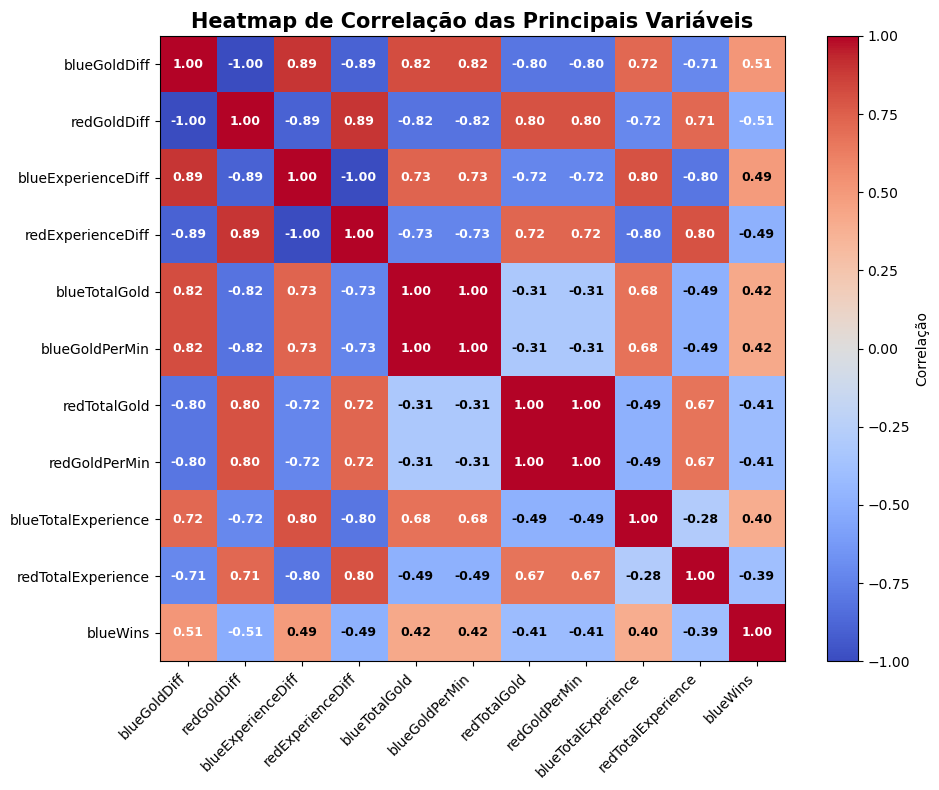

,blueGoldDiff,redGoldDiff,blueExperienceDiff,redExperienceDiff,blueTotalGold,blueGoldPerMin,redTotalGold,redGoldPerMin,blueTotalExperience,redTotalExperience,blueWins
blueGoldDiff,1.000000,-1.000000,0.894729,-0.894729,0.816803,0.816803,-0.804347,-0.804347,0.717968,-0.714405,0.511119
redGoldDiff,-1.000000,1.000000,-0.894729,0.894729,-0.816803,-0.816803,0.804347,0.804347,-0.717968,0.714405,-0.511119
blueExperienceDiff,0.894729,-0.894729,1.000000,-1.000000,0.729345,0.729345,-0.721190,-0.721190,0.800815,-0.800089,0.489558
redExperienceDiff,-0.894729,0.894729,-1.000000,1.000000,-0.729345,-0.729345,0.721190,0.721190,-0.800815,0.800089,-0.489558
blueTotalGold,0.816803,-0.816803,0.729345,-0.729345,1.000000,1.000000,-0.314212,-0.314212,0.676193,-0.491268,0.417213
blueGoldPerMin,0.816803,-0.816803,0.729345,-0.729345,1.000000,1.000000,-0.314212,-0.314212,0.676193,-0.491268,0.417213
redTotalGold,-0.804347,0.804347,-0.721190,0.721190,-0.314212,-0.314212,1.000000,1.000000,-0.485059,0.669646,-0.411396
redGoldPerMin,-0.804347,0.804347,-0.721190,0.721190,-0.314212,-0.314212,1.000000,1.000000,-0.485059,0.669646,-0.411396
blueTotalExperience,0.717968,-0.717968,0.800815,-0.800815,0.676193,0.676193,-0.485059,-0.485059,1.000000,-0.281446,0.396141
redTotalExperience,-0.714405,0.714405,-0.800089,0.800089,-0.491268,-0.491268,0.669646,0.669646,-0.281446,1.000000,-0.387588


In [45]:
# Seleciona as 10 variáveis mais correlacionadas com o alvo:
principais_variaveis = (
    correlacoes.abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

# Matriz de correlação
matriz_corr = df[principais_variaveis + ["blueWins"]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

plt.imshow(matriz_corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(matriz_corr.columns)),
    matriz_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_corr.index)),
    matriz_corr.index
)

# Adiciona os valores dentro das células
for i in range(len(matriz_corr.index)):
    for j in range(len(matriz_corr.columns)):
        valor = matriz_corr.iloc[i, j]
        plt.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            color="white" if abs(valor) > 0.5 else "black",
            fontsize=9,
            fontweight="bold"
        )

plt.title(
    "Heatmap de Correlação das Principais Variáveis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

display(matriz_corr)

**O heatmap evidencia quais indicadores apresentam maior relação com a vitória do time azul. Variáveis com maior correlação representam fatores que tendem a exercer maior influência no resultado da partida. Essa análise auxilia na identificação dos atributos mais relevantes e orienta tanto a seleção de variáveis quanto a interpretação do comportamento do modelo.**

### Distribuição da variável alvo

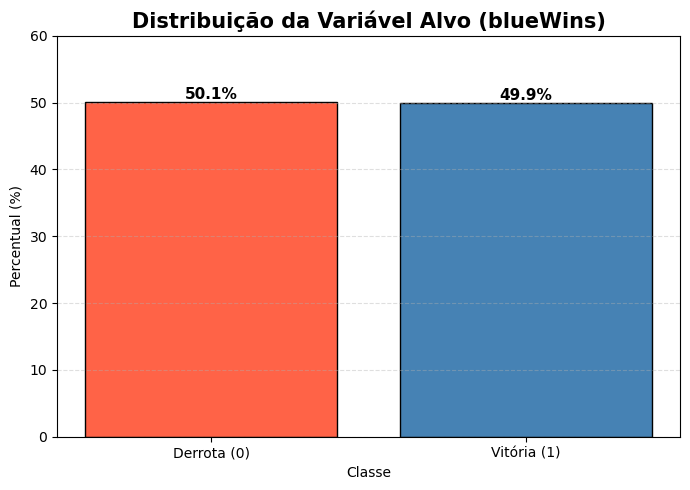

In [50]:
# Calcula a porcentagem de cada classe
percentual = df["blueWins"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["Derrota (0)", "Vitória (1)"],
    percentual.values,
    color=["tomato", "steelblue"],
    edgecolor="black"
)

# Exibe somente a porcentagem
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.5,
        f"{altura:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Distribuição da Variável Alvo (blueWins)", fontsize=15, fontweight="bold")
plt.xlabel("Classe")
plt.ylabel("Percentual (%)")
plt.ylim(0, 60)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**O gráfico mostra a proporção de vitórias e derrotas do time azul no conjunto de dados. Observa-se que as duas classes possuem distribuição bastante semelhante, indicando que a base está equilibrada. Esse equilíbrio é importante porque reduz o risco de o modelo favorecer apenas um dos resultados, aumentando a confiabilidade das previsões.**

### Conclusão das Visualizações:

**As visualizações demonstram que o conjunto de dados apresenta boa qualidade e equilíbrio, permitindo o treinamento de modelos confiáveis. Entre os algoritmos avaliados, o Gradient Boosting Tunado obteve o melhor desempenho, alcançando elevada capacidade de distinguir vitórias e derrotas. Além disso, a análise de importância das variáveis oferece transparência sobre os fatores que mais influenciam as previsões, tornando o modelo não apenas preciso, mas também interpretável e útil para apoiar decisões relacionadas ao desempenho das equipes.**

### Contexto
Desenvolver um modelo capaz de prever o vencedor de partidas ranqueadas de League of Legends utilizando informações dos primeiros minutos do jogo.

### Processo
- Análise exploratória;
- Engenharia de atributos;
- Treinamento e comparação de modelos;
- Ajuste de hiperparâmetros;
- Avaliação por Acurácia, Precisão, Recall, F1-Score, AUC e Log Loss.

### Recomendações
- Priorizar estratégias voltadas ao ganho de ouro e controle de objetivos.
- Utilizar o modelo como apoio à tomada de decisão.
- Evoluir futuramente para uma aplicação em Streamlit e testar modelos mais avançados.

### Estrutura usada no projeto 
1. Problema de negócio
2. Objetivo
3. Base de dados
4. EDA
5. Preparação dos dados
6. Modelos testados
7. Resultados
8. Variáveis mais importantes
9. Insights para o negócio
10. Conclusões e próximos passos

## Interpretação dos Resultados

O modelo final apresentou bom desempenho (AUC ≈ 0,81), demonstrando capacidade consistente de diferenciar vitórias e derrotas do time azul. Em termos de negócio, isso significa que é possível identificar, ainda no início da partida, sinais relevantes sobre o provável vencedor.

### Principais insights
- A vantagem de ouro foi o fator mais relevante.
- O controle de objetivos (dragões e monstros épicos) aumenta significativamente a chance de vitória.
- Vantagens econômicas e de experiência são mais importantes do que eliminações isoladas.